In [12]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 깨짐 방지 설정 (Windows 기준 맑은 고딕 적용)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 경고 메시지들 숨기기 (openpyxl 및 pandas 날짜 경고)
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")
warnings.filterwarnings("ignore", category=UserWarning, module="pandas")

# 엑셀 파일 로드 (상단의 불필요한 설정 정보 6개 행을 날리기)
trand_df = pd.read_excel('../../data/raw/trand/datalab.xlsx', skiprows=6, header=None)

# 데이터 정제 및 새로운 데이터프레임 생성
clean_trend = pd.DataFrame({
    # 1. 여기서 한 번에 format 지정을 끝냅니다!
    'date': pd.to_datetime(trand_df.iloc[:, 0], format='%Y-%m-%d', errors='coerce'),  
    '배달앱_검색량': pd.to_numeric(trand_df.iloc[:, 1], errors='coerce'),
    '실내_검색량': pd.to_numeric(trand_df.iloc[:, 3], errors='coerce'),
    '폭염_검색량': pd.to_numeric(trand_df.iloc[:, 5], errors='coerce'),
    '한파_검색량': pd.to_numeric(trand_df.iloc[:, 7], errors='coerce')
})

clean_trend = clean_trend.dropna(subset=['date'])

# 출력하여 확인
print(clean_trend)
print(clean_trend.isna().sum())

           date   배달앱_검색량    실내_검색량   폭염_검색량    한파_검색량
1    2022-01-01  21.24801  44.51906  5.41387  20.24366
2    2022-01-02  21.09035  28.11466  5.98413  19.95290
3    2022-01-03  19.85461  18.72741  5.35346  20.23752
4    2022-01-04  19.50755  18.20322  5.33811  18.92705
5    2022-01-05  19.94778  17.00742  5.19887  19.15024
...         ...       ...       ...      ...       ...
1457 2025-12-27  10.45815  30.28512  3.81162  26.82160
1458 2025-12-28   8.90811  28.83030  4.54671  22.34758
1459 2025-12-29   9.20092  19.66521  4.16790  15.70821
1460 2025-12-30   8.78116  18.96186  4.05938  15.89864
1461 2025-12-31  11.32531  24.68492  3.67340  19.94266

[1461 rows x 5 columns]
date       0
배달앱_검색량    0
실내_검색량     0
폭염_검색량     0
한파_검색량     0
dtype: int64


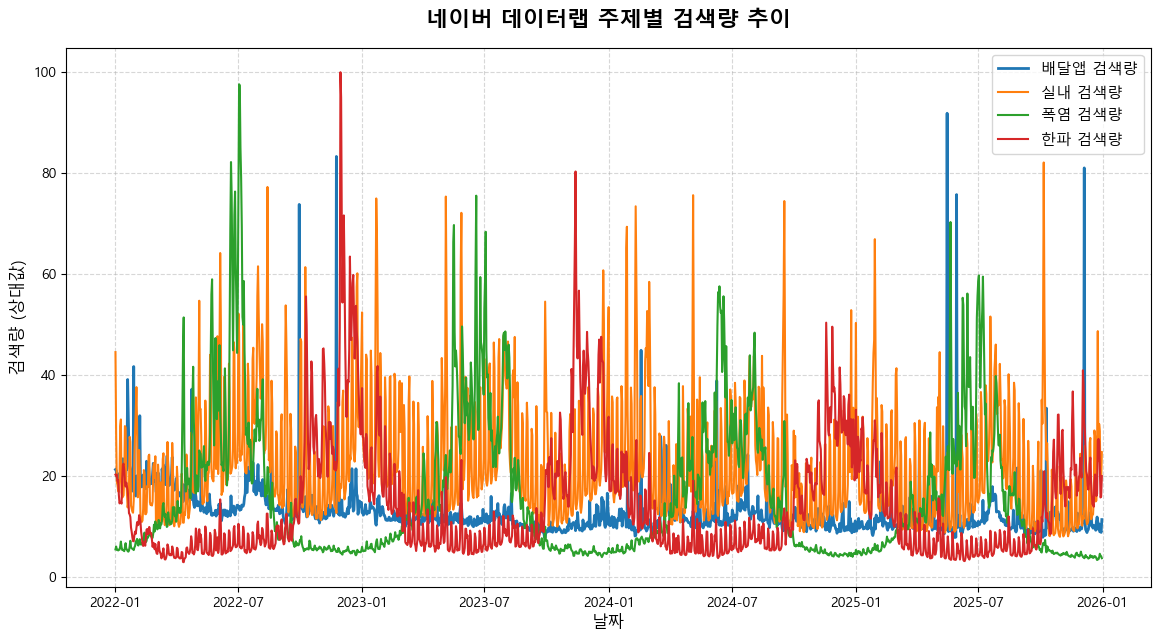

In [14]:
# 데이터 시각화 
plt.figure(figsize=(14, 7)) 


# 날짜를 X축으로 하고, 각 검색량 컬럼들을 선 그래프로 시각화
sns.lineplot(data=clean_trend, x='date', y='배달앱_검색량', label='배달앱 검색량', linewidth=2)
sns.lineplot(data=clean_trend, x='date', y='실내_검색량', label='실내 검색량', linewidth=1.5)
sns.lineplot(data=clean_trend, x='date', y='폭염_검색량', label='폭염 검색량', linewidth=1.5)
sns.lineplot(data=clean_trend, x='date', y='한파_검색량', label='한파 검색량', linewidth=1.5)

# 그래프 제목 및 레이블 설정
plt.title('네이버 데이터랩 주제별 검색량 추이', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('날짜', fontsize=12)
plt.ylabel('검색량 (상대값)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5) 
plt.legend(fontsize=11) 


plt.show()

In [16]:
output_path = '../../data/processed/clean_datalab_trend.xlsx'

clean_trend.to_excel('clean_datalab_trend.xlsx', index=False)